# Formula 1 2025 Race Results Web Scraping and Data Analysis

## Project Objective

### The objective of this project is to:

#### - Scrape Formula 1 race results data from the official F1 website.
#### - Convert unstructured web data into a structured dataset.
#### - Perform data cleaning and preprocessing.
#### - Conduct Exploratory Data Analysis (EDA).
#### - Create visualizations to identify winning trends among drivers and teams.

##  Import Libraries

In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns

## Explanation
#### pandas → Data manipulation and analysis.
#### requests → Sends HTTP requests to the website.
#### BeautifulSoup → Parses HTML content.
#### matplotlib → Data visualization.
#### seaborn → Advanced statistical visualization.

# Step-1 : Web Scraping

In [2]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/114.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
}

#### Some websites block automated requests. Adding a User-Agent makes the request look like it came from a browser.

In [3]:
def get_soup(url):
    response = requests.get(url, headers=HEADERS, timeout=15)
    response.raise_for_status()
    return BeautifulSoup(response.text, "html.parser")

#### Sends request to website.
#### Downloads webpage source.
#### Converts HTML into BeautifulSoup object.

## Scrape Race Results

In [4]:
race_url = "https://www.formula1.com/en/results/2025/races"
soup_races = get_soup(race_url)
table = soup_races.find("div", id="results-table")

if table is None:
    table = soup_races.find("table")

rows = []

if table:

    headers = [th.get_text(strip=True) for th in table.find_all("th")]
    print("Columns Found:")
    print(headers)

    for tr in table.find_all("tr")[1:]:

        cells = tr.find_all("td")

        if not cells:
            continue

        gp_link = cells[0].find("a")
        grand_prix = (
            gp_link.get_text(strip=True)
            if gp_link
            else cells[0].get_text(strip=True)
        )

        date = cells[1].get_text(strip=True)

        winner = cells[2].get_text(" ", strip=True)

        team = cells[3].get_text(" ", strip=True)

        laps = cells[4].get_text(strip=True)

        time = cells[5].get_text(strip=True)

        rows.append({
            "Grand Prix": grand_prix,
            "Date": date,
            "Winner": winner,
            "Team": team,
            "Laps": laps,
            "Time": time
        })

print("Total Races Scraped:", len(rows))

Columns Found:
['Grand Prix', 'Date', 'Winner', 'Team', 'Laps', 'Time']
Total Races Scraped: 24


# Step-2 : Create DataFrame

#### Convert scraped data into tabular format.

In [5]:
df_races = pd.DataFrame(rows)

df_races.head()

,Grand Prix,Date,Winner,Team,Laps,Time
0,Flag of AustraliaAustralia,16 Mar,Lando Norris NOR,McLaren,57,1:42:06.304
1,Flag of People’s Republic of ChinaChina,23 Mar,Oscar Piastri PIA,McLaren,56,1:30:55.026
2,Flag of JapanJapan,06 Apr,Max Verstappen VER,Red Bull Racing,53,1:22:06.983
3,Flag of BahrainBahrain,13 Apr,Oscar Piastri PIA,McLaren,57,1:35:39.435
4,Flag of Saudi ArabiaSaudi Arabia,20 Apr,Oscar Piastri PIA,McLaren,50,1:21:06.758


In [6]:
# Save Dataset
df_races.to_csv(
    "f1_2025_race_results.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [7]:
df_races.to_csv("race_schedule.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!






# ---------------------------





## DateFrame Created

In [8]:
df_races

,Grand Prix,Date,Winner,Team,Laps,Time
0,Flag of AustraliaAustralia,16 Mar,Lando Norris NOR,McLaren,57,1:42:06.304
1,Flag of People’s Republic of ChinaChina,23 Mar,Oscar Piastri PIA,McLaren,56,1:30:55.026
2,Flag of JapanJapan,06 Apr,Max Verstappen VER,Red Bull Racing,53,1:22:06.983
3,Flag of BahrainBahrain,13 Apr,Oscar Piastri PIA,McLaren,57,1:35:39.435
4,Flag of Saudi ArabiaSaudi Arabia,20 Apr,Oscar Piastri PIA,McLaren,50,1:21:06.758
5,Flag of United States of AmericaMiami,04 May,Oscar Piastri PIA,McLaren,57,1:28:51.587
6,Flag of ItalyEmilia-Romagna,18 May,Max Verstappen VER,Red Bull Racing,63,1:31:33.199
7,Flag of MonacoMonaco,25 May,Lando Norris NOR,McLaren,78,1:40:33.843
8,Flag of SpainSpain,01 Jun,Oscar Piastri PIA,McLaren,66,1:32:57.375
9,Flag of CanadaCanada,15 Jun,George Russell RUS,Mercedes,70,1:31:52.688


# Step-3 : DATA UNDERSTANDING

In [9]:
print("Rows, Columns:", df_races.shape)

Rows, Columns: (24, 6)


## Data Types

In [10]:
df_races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Grand Prix  24 non-null     object
 1   Date        24 non-null     object
 2   Winner      24 non-null     object
 3   Team        24 non-null     object
 4   Laps        24 non-null     object
 5   Time        24 non-null     object
dtypes: object(6)
memory usage: 1.3+ KB


### Statistical Summary

In [11]:
df_races.describe(include="all")

,Grand Prix,Date,Winner,Team,Laps,Time
count,24,24,24,24,24,24
unique,24,24,4,3,15,24
top,Flag of AustraliaAustralia,16 Mar,Max Verstappen VER,McLaren,57,1:42:06.304
freq,1,1,8,14,4,1


## Missing Values

In [12]:
df_races.isnull().sum()

Grand Prix    0
Date          0
Winner        0
Team          0
Laps          0
Time          0
dtype: int64

## Duplicate Records

In [13]:
df_races.duplicated().sum()

np.int64(0)

In [14]:
df_races.drop_duplicates(inplace=True)

## Remove Extra Spaces

In [15]:
df_races["Grand Prix"] = df_races["Grand Prix"].str.strip()
df_races["Winner"] = df_races["Winner"].str.strip()
df_races["Team"] = df_races["Team"].str.strip()

In [16]:
df_races["Laps"] = pd.to_numeric(
    df_races["Laps"],
    errors="coerce"
)

In [17]:
df_races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Grand Prix  24 non-null     object
 1   Date        24 non-null     object
 2   Winner      24 non-null     object
 3   Team        24 non-null     object
 4   Laps        24 non-null     int64 
 5   Time        24 non-null     object
dtypes: int64(1), object(5)
memory usage: 1.3+ KB


### Data_type change

In [18]:
df_races['Time'] =pd.to_datetime (df_races['Time'])

C:\Users\moham\AppData\Local\Temp\ipykernel_6464\4153408361.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_races['Time'] =pd.to_datetime (df_races['Time'])


In [19]:
df_races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Grand Prix  24 non-null     object        
 1   Date        24 non-null     object        
 2   Winner      24 non-null     object        
 3   Team        24 non-null     object        
 4   Laps        24 non-null     int64         
 5   Time        24 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 1.3+ KB


# EXPLORATORY DATA ANALYSIS (EDA)

###  Number of Races

In [20]:
print("Total Races:", len(df_races))

Total Races: 24


### Driver Wins

In [21]:
driver_wins = df_races["Winner"].value_counts()

print(driver_wins)

Winner
Max Verstappen VER    8
Lando Norris NOR      7
Oscar Piastri PIA     7
George Russell RUS    2
Name: count, dtype: int64


### Team Wins

In [22]:
team_wins = df_races["Team"].value_counts()

print(team_wins)

Team
McLaren            14
Red Bull Racing     8
Mercedes            2
Name: count, dtype: int64


### Average Laps

In [23]:
print(
    "Average Laps:",
    round(df_races["Laps"].mean(),2)
)

Average Laps: 60.17


### Longest Race

In [24]:
df_races.loc[df_races['Laps'].idxmax()]

Grand Prix          Flag of MonacoMonaco
Date                              25 May
Winner                  Lando Norris NOR
Team                             McLaren
Laps                                  78
Time          2026-06-29 01:40:33.843000
Name: 7, dtype: object

### Shortest Race

In [25]:
df_races.loc[df_races['Laps'].idxmin()]

Grand Prix        Flag of BelgiumBelgium
Date                              27 Jul
Winner                 Oscar Piastri PIA
Team                             McLaren
Laps                                  44
Time          2026-06-29 01:25:22.601000
Name: 12, dtype: object

# Step-4 : VISUALIZATION

## Driver Wins

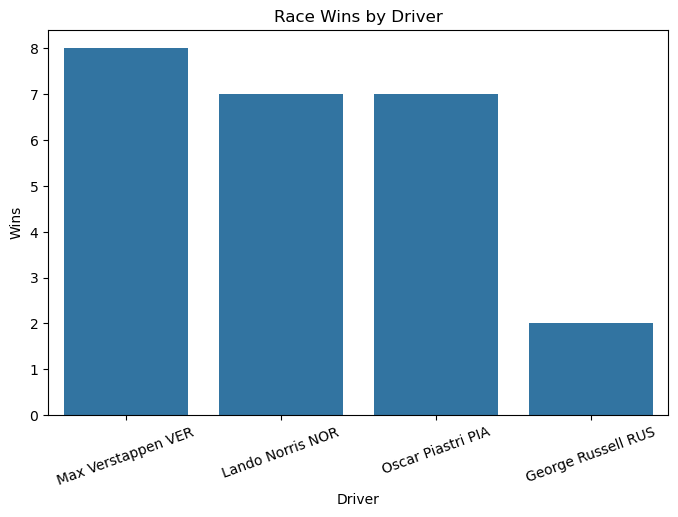

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_races,
    x="Winner",
    order=df_races["Winner"].value_counts().index
)

plt.title("Race Wins by Driver")
plt.xlabel("Driver")
plt.ylabel("Wins")
plt.xticks(rotation=20)

plt.show()

## Driver Win Percentage

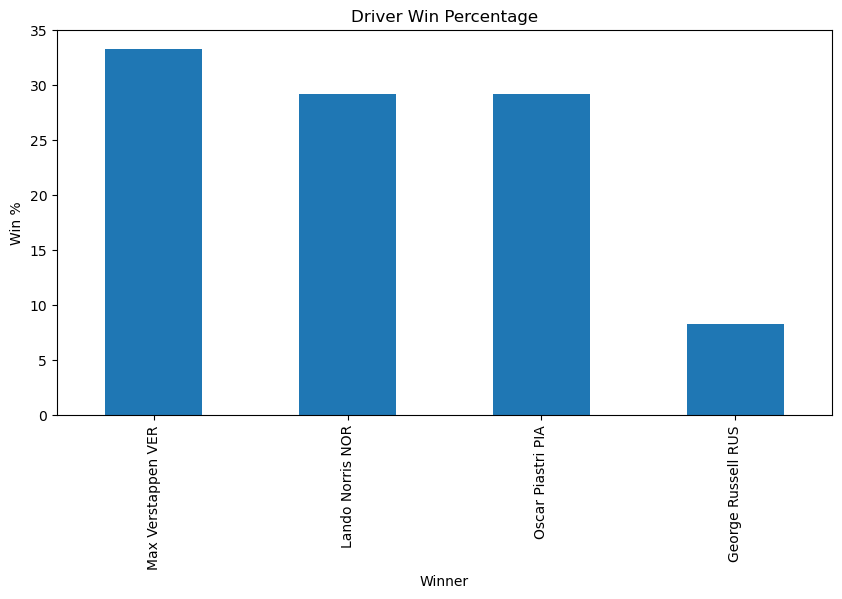

In [27]:
driver_win_pct = (df_races['Winner'].value_counts()/len(df_races))*100

driver_win_pct.plot(
    kind='bar',
    figsize=(10,5),
    title='Driver Win Percentage'
)
plt.ylabel('Win %')
plt.show()

## Team Wins

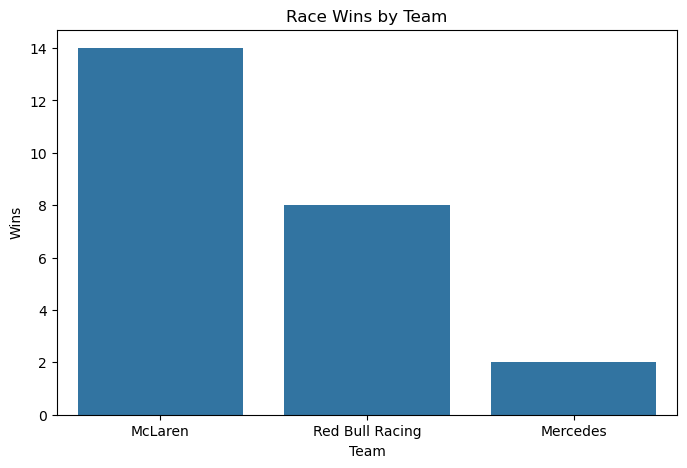

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_races,
    x="Team",
    order=df_races["Team"].value_counts().index
)

plt.title("Race Wins by Team")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.show()

### Team win percentage

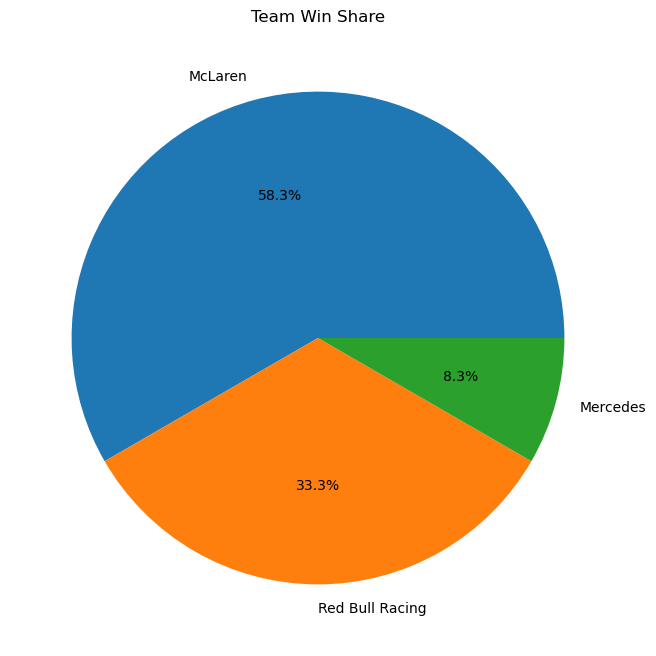

In [29]:
team_win_pct = (df_races['Team'].value_counts()/len(df_races))*100
plt.figure(figsize=(8,8))
team_win_pct.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Team Win Share')
plt.ylabel('')
plt.show()

## Laps Distribution

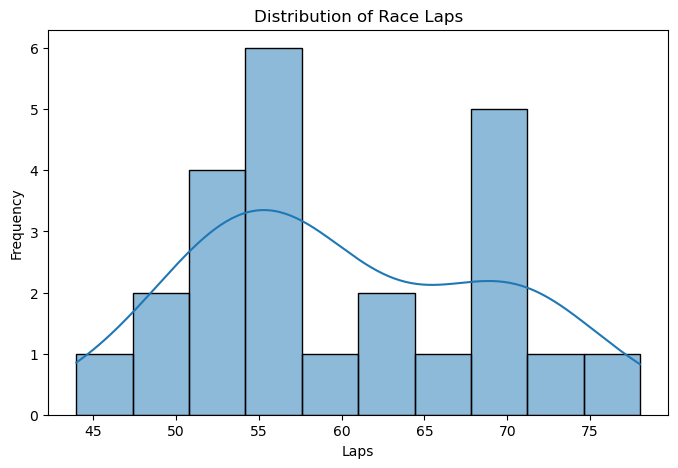

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_races["Laps"],
    bins=10,
    kde=True
)

plt.title("Distribution of Race Laps")
plt.xlabel("Laps")
plt.ylabel("Frequency")

plt.show()


## Top Drivers Bar Plot

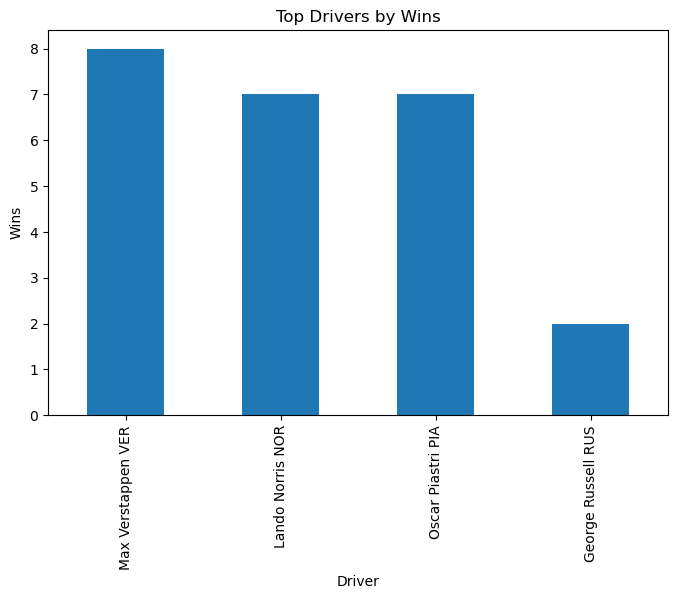

In [31]:
wins = df_races["Winner"].value_counts()

plt.figure(figsize=(8,5))

wins.plot(kind="bar")

plt.title("Top Drivers by Wins")
plt.xlabel("Driver")
plt.ylabel("Wins")

plt.show()

### Boxplot of Laps

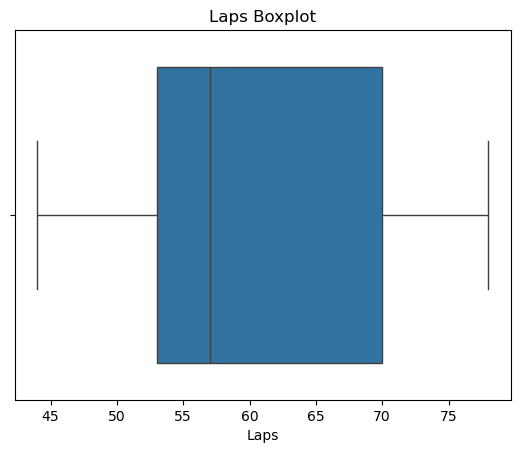

In [32]:
sns.boxplot(
    x=df_races['Laps']
)

plt.title('Laps Boxplot')
plt.show()

## Grand Prix vs Laps

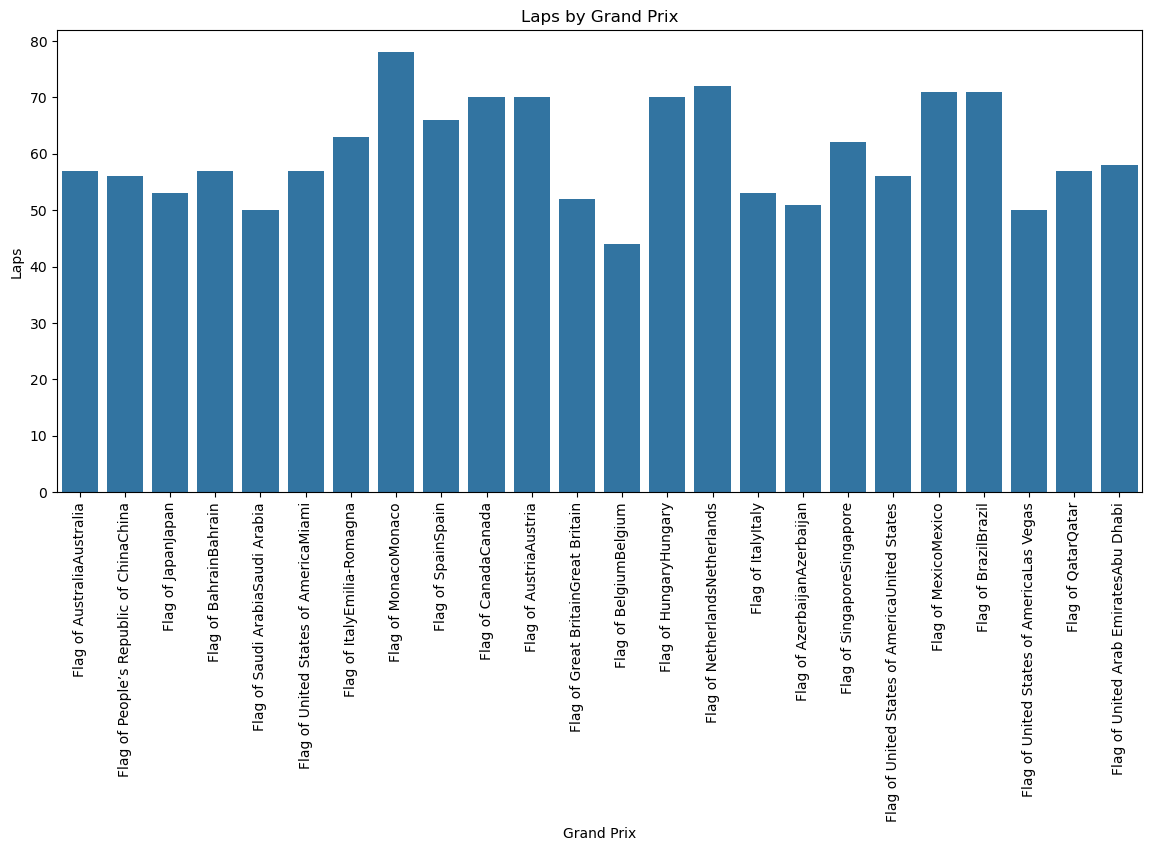

In [33]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=df_races,
    x="Grand Prix",
    y="Laps"
)

plt.xticks(rotation=90)

plt.title("Laps by Grand Prix")

plt.show()

## Heatmap

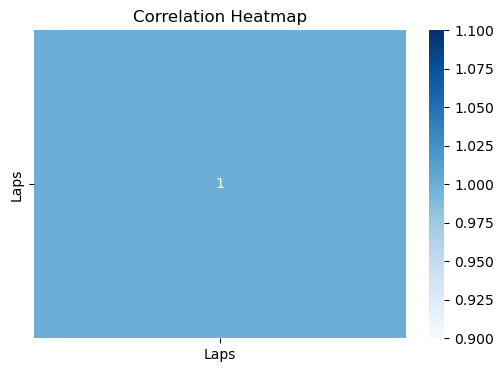

In [34]:



plt.figure(figsize=(6,4))

sns.heatmap(
    df_races[["Laps"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

### Team vs Driver Matrix

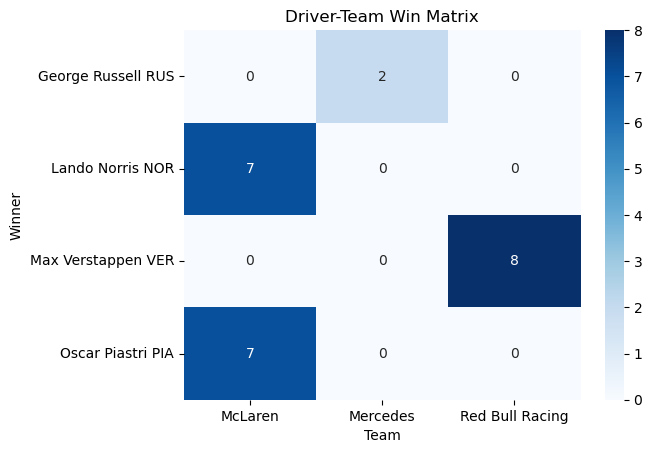

In [35]:
pivot = pd.crosstab(
    df_races['Winner'],
    df_races['Team']
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='Blues'
)

plt.title('Driver-Team Win Matrix')
plt.show()

# Conclusion

This project successfully scraped Formula 1 2025 race data from the official website and transformed raw web data into a structured analytical dataset. Through exploratory data analysis and visualizations, valuable insights regarding driver dominance, team performance, and race characteristics were identified.

The analysis revealed that McLaren was the most successful team, while Max Verstappen emerged as the top-performing driver. Additionally, race lap distributions highlighted the diversity of Formula 1 circuits and strategies across different Grand Prix events.

Overall, this project demonstrates practical skills in Web Scraping, Data Cleaning, Data Analysis, Data Visualization, and Python Programming, making it an excellent portfolio project for Data Analyst and Data Science roles.

In [36]:
print("Top Driver:")
print(df_races["Winner"].value_counts().idxmax())

print("\nTop Team:")
print(df_races["Team"].value_counts().idxmax())

print("\nAverage Laps:")
print(round(df_races["Laps"].mean(),2))

Top Driver:
Max Verstappen VER

Top Team:
McLaren

Average Laps:
60.17




###### 